# Data Visualization: Claim Critique and Alternative Design

This portfolio project critiques three published charts across energy, economics, and public health. It redesigns each view for a clearer analytical task, records the chart-choice rationale, and audits factual claims against the supplied data.

In [279]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



## Artefact 1: US electricity generation

In [280]:
# ---- Artefact 1 identifying information (META_1, G1), PRIMARY ----
# META means metadata: information identifying the chart. The _1 means artefact 1.
META_1 = {
    "artefact_id": "POOL-10",          # from the released pool, e.g. "POOL-03"
    "domain": "energy",               # copy the exact domain from the pool row/provenance sheet
    "source_url": "https://www.eia.gov/energyexplained/electricity/electricity-in-the-us.php",           # where the original chart was published
    "publisher": "US Energy Information Administration",
    "publication_date": "2025 data; page updated 2026",     # copy the pool row/provenance value
    "data_status": "supplied",     # keep as "supplied"
}

### Critique

In [281]:
# ---- Full 9-field critique, artefact 1 (G5 structure, H1 insight) ----
critique_1 = {
    "main_claim": "The chart shows how US electricity generation in 2025 is divided among major energy sources, with natural gas providing the largest share among the major sources.",
    "audience": "students, energy policymakers, energy analysts, and the general public interested in energy production.",
    "visual_task": "Compare the relative shares of electricity generation sources.",
    "directly_visible": "Natural gas has the largest displayed share; nuclear, coal and renewables make up the remaining major shares.",
    "interpretation_not_observation": "The large share of natural gas can be interpreted as indicating that natural gas played a major role in US electricity generation in 2025. ",
    "what_is_omitted": "The chart does not show costs, emissions, reliability, capacity factors and environmental impacts are not shown.",
    "what_misleads": "The chart may mislead readers to focus on percentages without considering the actual generation or other dimensions.",
    "what_needs_verifying": "Claims about which source is preferable require cost, emissions and reliability data.",
    "repaired_caption": "US electricity generation in 2025 was distributed across several major sources, with natural gas accounting for the largest share at 40.8%; the shares describe the composition of generation and do not by themselves indicate absolute output, cost, emissions, or reliability.",
}

### Data

In [282]:
# ---- Artefact 1 data (G2, H2) ----

# Describe every filter, reshape, derived field or other transformation.
# If none, state that you used the supplied rows and fields unchanged.
TRANSFORMATION_NOTE_1 = "No transformations were applied to the supplied data; the rows and fields were used unchanged."
data_1.head()

,energy_source,parent_source,level,share_pct,approx_billion_kwh,display_order
0,Natural gas,NaN,major,40.8,1807.4,1
1,Coal,NaN,major,16.6,735.4,2
2,Nuclear,NaN,major,17.7,784.1,3
3,Renewables,NaN,major,24.1,1067.6,4
4,Petroleum and other,NaN,major,0.7,31.0,5


In [283]:
data_1.describe()

,share_pct,approx_billion_kwh,display_order
count,10.000000,10.000000,10.00000
mean,12.410000,549.760000,5.50000
std,12.833848,568.528469,3.02765
min,0.400000,17.700000,1.00000
25%,2.150000,95.250000,3.25000
50%,8.600000,381.000000,5.50000
75%,17.425000,771.925000,7.75000
max,40.800000,1807.400000,10.00000


### Alternative view

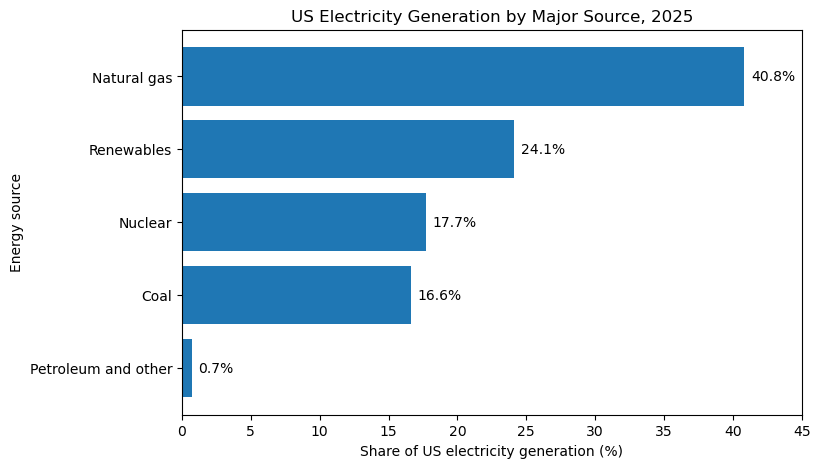

In [284]:
CATEGORY_1 = "part-to-whole"


def redesign_1(data_1: pd.DataFrame):
    """Alternative view of artefact 1 designed for your stated claim.

    State the reader's task in one sentence here. RETURN the Axes.
    """
    major = data_1[data_1["level"] == "major"].copy()

    major = major.sort_values("share_pct", ascending=True)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.barh(
        major["energy_source"],
        major["share_pct"]
    )

    ax.set_xlabel("Share of US electricity generation (%)")
    ax.set_ylabel("Energy source")
    ax.set_title("US Electricity Generation by Major Source, 2025")

    ax.set_xlim(0, 45)

    for i, value in enumerate(major["share_pct"]):
        ax.text(
            value + 0.5,
            i,
            f"{value:.1f}%",
            va="center"
        )

    return ax


ax_1 = redesign_1(data_1)

### Chart choice decision record

In [285]:
decision_record_1 = {
    "intended_audience": "students, energy policymakers, energy analysts, and the general public interested in energy production.",
    "question_they_need_answered": "What share of US electricity generation came from each major energy source in 2025?",
    "decision_supported": "The alternative view supports direct comparison of the contribution of each major energy source to total US electricity generation.",
    "vocabulary_category": "part-to-whole",        # must match CATEGORY_1
    "required_comparison": "Compare the shares of total US electricity generation contributed by the five major energy sources.",
    "selected_form": "Horizontal bar chart",
    "why_it_fits": "Bar lengths provide a direct and precise comparison of the five source shares, while the common zero baseline makes the relative contributions easy to read.",                # explain why this form fits
    "rejected_alternative": "Pie chart",
    "reason_for_rejection": "A pie chart would make the small 0.7% petroleum-and-other share and the relatively close nuclear and coal shares harder to compare precisely.",       # give a specific reason
}

## Artefact 2: US income distribution

In [286]:
# ---- Artefact 2 identifying information (META_2, G1), ARTEFACT ----
# META means metadata: information identifying the chart. The _2 means artefact 2.
META_2 = {
    "artefact_id": "POOL-05",          # from the released pool, e.g. "POOL-03"
    "domain": "economics",               # copy the exact domain from the pool row/provenance sheet
    "source_url": "https://openstax.org/books/principles-economics-3e/pages/15-4-income-inequality-measurement-and-causes",           # where the original chart was published
    "publisher": "OpenStax",
    "publication_date": "2022",     # copy the pool row/provenance value
    "data_status": "supplied",     # keep as "supplied"
}

### Critique

In [287]:
# ---- Full 9-field critique, artefact 2 (G5 structure, H1 insight) ----
critique_2 = {
    "main_claim": "The chart compares income distribution in 1980 and 2020, showing that the gap between rich and poor widened over this period.",
    "audience": "economics students, policy-makers, and the general public interested in income inequality trends.",
    "visual_task": "Compare the income distribution between 1980 and 2020 to assess changes in inequality.",
    "directly_visible": "The 2020 line is below the 1980 line for much of the distribution.",
    "interpretation_not_observation": "The 2020 line can be interpreted as a more unequal distribution of family income than in 1980, because a smaller cumulative share of income is associated with the same cumulative share of families.",
    "what_is_omitted": "The chart does not show specific income levels, causes of inequality, or differences within population groups.",
    "what_misleads": "Readers may mistakely assume that the actual income fell in 2020.",
    "what_needs_verifying": "Claims about the causes or social consequences of inequality require additional evidence.",
    "repaired_caption": "The chart shows the cumulative income distribution for 1980 and 2020, indicating that income inequality has increased over this period.",
}

### Data

In [288]:
# ---- Artefact 2 data (G2, H2) ----

# Describe every filter, reshape, derived field or other transformation.
# If none, state that you used the supplied rows and fields unchanged.
TRANSFORMATION_NOTE_2 = "The supplied rows and fields unchanged."
data_2.head()


,population_share,income_share_1980,income_share_2020
0,0.0,0.000,0.000
1,0.2,0.043,0.030
2,0.4,0.146,0.112
3,0.6,0.315,0.258
4,0.8,0.563,0.480


In [289]:
data_2.describe()

,population_share,income_share_1980,income_share_2020
count,6.000000,6.000000,6.000000
mean,0.500000,0.344500,0.313333
std,0.374166,0.381386,0.379827
min,0.000000,0.000000,0.000000
25%,0.250000,0.068750,0.050500
50%,0.500000,0.230500,0.185000
75%,0.750000,0.501000,0.424500
max,1.000000,1.000000,1.000000


### Alternative view

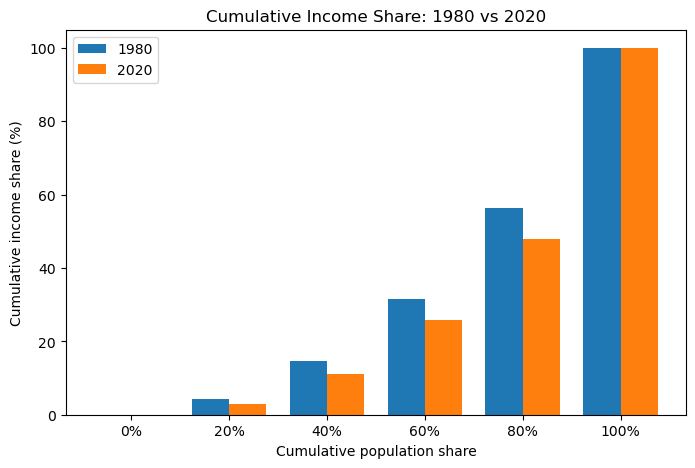

In [290]:
CATEGORY_2 = "distribution"


def redesign_2(data_2: pd.DataFrame):
    """Alternative view of artefact 2 designed for your stated claim.

    State the reader's task in one sentence here. RETURN the Axes.
    """
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(8, 5))

    x = range(len(data_2))
    width = 0.38

    ax.bar(
        [i - width / 2 for i in x],
        data_2["income_share_1980"] * 100,
        width=width,
        label="1980"
    )

    ax.bar(
        [i + width / 2 for i in x],
        data_2["income_share_2020"] * 100,
        width=width,
        label="2020"
    )

    ax.set_xticks(list(x))
    ax.set_xticklabels(
        [f"{int(v * 100)}%" for v in data_2["population_share"]]
    )

    ax.set_xlabel("Cumulative population share")
    ax.set_ylabel("Cumulative income share (%)")
    ax.set_title("Cumulative Income Share: 1980 vs 2020")
    ax.legend()

    ax.set_ylim(0, 105)

    return ax



ax_2 = redesign_2(data_2)

### Chart choice decision record

In [291]:
decision_record_2 = {
    "intended_audience": "economics students, policy-makers, and the general public interested in income inequality trends.",
    "question_they_need_answered": "At the same cumulative population shares, how do cumulative income shares differ between 1980 and 2020?",
    "decision_supported": "The alternative view supports direct comparison of cumulative income shares between 1980 and 2020 at each displayed population share.",
    "vocabulary_category": "distribution",        # must match CATEGORY_2
    "required_comparison": "Compare the 1980 and 2020 cumulative income shares at the same cumulative population shares.",
    "selected_form": "Grouped bar chart",
    "why_it_fits": "Two bars at each population share make the 1980 and 2020 values easy to compare directly, while the zero baseline preserves the magnitude of the income-share values.",                # explain why this form fits
    "rejected_alternative": "Stacked bar chart",
    "reason_for_rejection": "A stacked bar chart would make the two years harder to compare at each population share because the 2020 bars would not share the same visual baseline as the 1980 bars.",       # give a specific reason
}

## Artefact 3: Health expenditure and life expectancy

In [292]:
# ---- Artefact 3 identifying information (META_3, G1), ARTEFACT ----
# META means metadata: information identifying the chart. The _3 means artefact 3.
META_3 = {
    "artefact_id": "POOL-02",          # from the released pool, e.g. "POOL-03"
    "domain": "public health",               # copy the exact domain from the pool row/provenance sheet
    "source_url": "https://ourworldindata.org/grapher/life-expectancy-vs-health-expenditure",           # where the original chart was published
    "publisher": "Our World in Data",
    "publication_date": "Updated annually",     # copy the pool row/provenance value
    "data_status": "supplied",     # keep as "supplied"
}

### Critique

In [293]:
# ---- Full 9-field critique, artefact 3 (G5 structure, H1 insight) ----
critique_3 = {
    "main_claim": "Countries with higher health spending per capita generally have higher life expectancy, but there are exceptions.",
    "audience": "students, public-makers of healthcare, and general public interested in health-systems performance.",
    "visual_task": "Compare the relationship between health spending and life expectancy values and identify the overall trend formed by changes between these two variables across countries.",
    "directly_visible": "The chart shows individual countries as points. The horizontal axis represents health expenditure per capita, while the vertical axis represents life expectancy. The points generally rise from lower-left to upper-right.",
    "interpretation_not_observation": "The positive trend suggests a link between increased health spending and longer life expectancy, though individual country variations exist.",
    "what_is_omitted": "The chart does not show data on income levels, healthcare system efficiency, or other socioeconomic factors that could influence health outcomes.",
    "what_misleads": "The chart may mislead readers into assuming a direct causal relationship between health spending and life expectancy without considering other contributing factors.",
    "what_needs_verifying": "Checks on the 2023 data sources, methods of data collection, and potential confounding variables are necessary to verify the claims made in the chart.",
    "repaired_caption": "The chart displays the relationship between health expenditure per capita and life expectancy across countries, showing a general positive trend with some notable exceptions."
}

### Data

In [294]:
# ---- Artefact 3 data (G2, H2) ----

# Describe every filter, reshape, derived field or other transformation.
# If none, state that you used the supplied rows and fields unchanged.
TRANSFORMATION_NOTE_3 = "The supplied rows and fields unchanged."
data_3.head()

,country,code,year,life_expectancy_years,health_exp_per_capita_usd,region
0,Albania,ALB,2023,79.602,1224.075,Europe
1,Argentina,ARG,2023,77.395,2851.414,South America
2,Australia,AUS,2023,83.923,6075.151,Oceania
3,Austria,AUT,2023,81.956,6457.345,Europe
4,Belgium,BEL,2023,82.115,6150.812,Europe


In [295]:
data_3.describe()

,year,life_expectancy_years,health_exp_per_capita_usd
count,57.0,57.000000,57.000000
mean,2023.0,79.507632,3723.906544
std,0.0,3.840910,2309.334884
min,2023.0,66.139000,312.491000
25%,2023.0,77.156000,1807.580000
50%,2023.0,80.799000,3144.941000
75%,2023.0,82.360000,5399.139000
max,2023.0,84.712000,12098.848000


### Alternative view

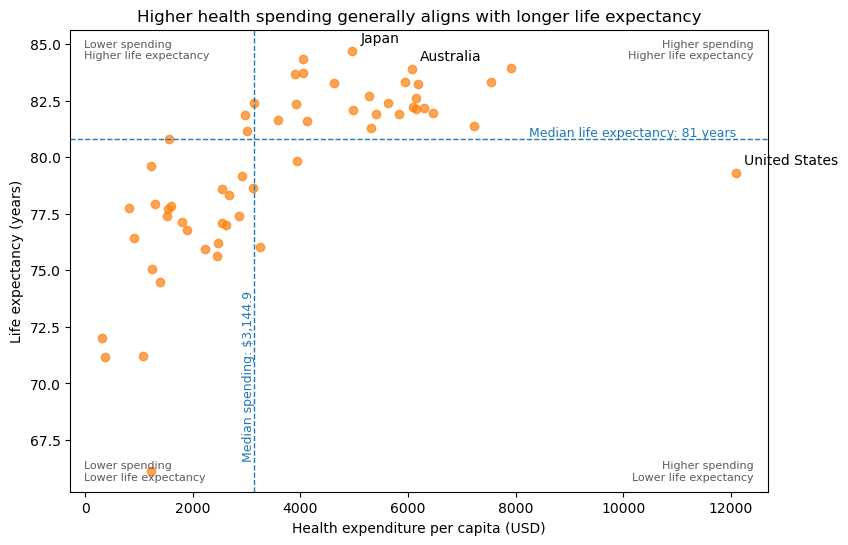

In [296]:
CATEGORY_3 = "correlation"


def redesign_3(data_3: pd.DataFrame):
    """Alternative view of artefact 3 designed for your stated claim.

    State the reader's task in one sentence here. RETURN the Axes.
    """
    fig, ax = plt.subplots(figsize=(9, 6))

    x = data_3["health_exp_per_capita_usd"]
    y = data_3["life_expectancy_years"]

    # Calculate median reference values
    x_median = x.median()
    y_median = y.median()

    # Plot countries
    ax.scatter(
    x,
    y,
    alpha=0.7,
    color="tab:orange"
)

    # Add median reference lines
    ax.axvline(x_median, linestyle="--", linewidth=1)
    ax.axhline(y_median, linestyle="--", linewidth=1)

    # Labels for median reference lines
    ax.text(
        x_median - 100,
        y.min() + 8,
        f"Median spending: ${x_median:,.1f}",
        ha="center",
        va="top",
        rotation=90,
        fontsize=9,
        color="tab:blue"
    )

    ax.text(
        x.max(),
        y_median,
        f"Median life expectancy: {y_median:.0f} years",
        ha="right",
        va="bottom",
        fontsize=9,
        color="tab:blue"
    )
    
    # Highlight selected countries
    highlight = ["Australia", "Japan", "United States"]


    for _, row in data_3[data_3["country"].isin(highlight)].iterrows():
        ax.annotate(
            row["country"],
            (row["health_exp_per_capita_usd"], row["life_expectancy_years"]),
            xytext=(6, 6),
            textcoords="offset points"
        )

    ax.set_xlabel("Health expenditure per capita (USD)")
    ax.set_ylabel("Life expectancy (years)")

    ax.set_title(
        "Higher health spending generally aligns with longer life expectancy"
    )

    # Quadrant labels
    ax.text(
        0.02, 0.98,
        "Lower spending\nHigher life expectancy",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8,
        color="0.35"
    )

    ax.text(
        0.98, 0.98,
        "Higher spending\nHigher life expectancy",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        color="0.35"
    )

    ax.text(
        0.02, 0.02,
        "Lower spending\nLower life expectancy",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=8,
        color="0.35"
    )

    ax.text(
        0.98, 0.02,
        "Higher spending\nLower life expectancy",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        color="0.35"
    )
    return ax


ax_3 = redesign_3(data_3)

### Chart choice decision record

In [297]:
decision_record_3 = {
    "intended_audience": "students, public-makers of healthcare, and general public interested in health-systems performance.",
    "question_they_need_answered": "How does health expenditure per capita relate to life expectancy across countries, and are there notable exceptions to the general trend?",
    "decision_supported": "The alternative view supports identifying the overall positive association between health spending and life expectancy while making deviations from the pattern easier to see.",
    "vocabulary_category": "correlation",        # must match CATEGORY_3
    "required_comparison": "Compare countries across the median health expenditure and median life expectancy to identify which countries are above or below the median in both dimensions.",
    "selected_form": "Median-based quadrant scatter plot",
    "why_it_fits": "The scatter plot preserves the relationship between the two numerical variables, while the two median reference lines divide countries into four groups and make the overall association and exceptions easier to interpret.",                # explain why this form fits
    "rejected_alternative": "Heatmap",
    "reason_for_rejection": "A heatmap would require grouping health spending and life expectancy into bins, which would hide individual countries and make important exceptions such as the United States harder to identify.",       # give a specific reason
}

## Claim audits

### Artefact 1 audit

In [298]:
generated_interpretation_1 = """
The data shows a clear concentration of US electricity generation among several major sources. Natural gas is the largest source, accounting for 40.8% of generation and producing more than 1,800 billion kWh. Renewables are the second-largest category at 24.1%, followed by nuclear power at 17.7% and coal at 16.6%. This means natural gas alone contributes more generation than any other individual source, while nuclear slightly exceeds coal. Petroleum contributes only 0.7%, making it a very small component of the overall generation mix.
The comparison suggests that the US electricity mix is dominated by natural gas and includes substantial contributions from both renewable and nuclear generation. However, the dataset alone does not establish why these sources have the observed shares. Factors such as technology costs, fuel availability and energy policy may contribute, but these explanations require additional evidence. Similarly, the data does not by itself establish that coal is in a “terminal decline” or predict how the electricity mix will change in the future. Further time-series data and external evidence would be needed to assess these trends and explain their causes. Future changes may involve different combinations of fossil, nuclear and renewable generation, but the direction and drivers cannot be determined from these values alone.
"""

In [299]:
# ---- Claims (G4, H5). Keys are short paraphrases of each claim. ----
claims_1 = {
    "Natural gas accounts for 40.8% of US electricity generation": "supported",   # supported / plausible but unverified / unsupported / contradicted
    "Renewables account for 24.1% of generation": "supported",
    "Nuclear generation exceeds coal generation": "supported",
    "Petroleum and other sources contribute only 0.7% of generation": "supported",
    "Technology costs and fuel availability explain the observed energy mix": "plausible but unverified",
    "The future electricity mix will depend on balancing gas and renewables": "plausible but unverified"
}

probes_1 = {
    # required for every supported/contradicted claim:
    # "example claim one": lambda: data_1.groupby(...)...,
    "Natural gas accounts for 40.8% of US electricity generation":
        lambda: data_1.loc[
            data_1["energy_source"] == "Natural gas",
            ["energy_source", "share_pct", "approx_billion_kwh"]
        ],

    "Renewables account for 24.1% of generation":
        lambda: data_1.loc[
            data_1["energy_source"] == "Renewables",
            ["energy_source", "share_pct", "approx_billion_kwh"]
        ],

    "Nuclear generation exceeds coal generation":
        lambda: data_1.loc[
            data_1["energy_source"].isin(["Nuclear", "Coal"]),
            ["energy_source", "share_pct", "approx_billion_kwh"]
        ].sort_values("share_pct", ascending=False),

    "Petroleum and other sources contribute only 0.7% of generation":
        lambda: data_1.loc[
            data_1["energy_source"] == "Petroleum and other",
            ["energy_source", "share_pct", "approx_billion_kwh"]
        ]
}

### Artefact 2 audit

In [300]:
generated_interpretation_2 = """
The data show a clear shift in the distribution of income between 1980 and 2020. The share of income received by the bottom 80% decreased from 56.3% in 1980 to 48.0% in 2020, while the top 20% increased its share from 43.7% to 52.0%. This represents a substantial widening of the gap between the highest and lower income groups. The lowest 20% also experienced a decline, with its income share falling from 4.3% to 3.0%. These figures indicate that a larger proportion of total income was concentrated among the highest-earning group by 2020. However, the dataset describes changes in income shares but does not establish the causes of these changes. Factors such as technological change, globalisation, or changes in labour-market institutions may be relevant explanations, but they require additional evidence to verify. Similarly, the data alone cannot predict the social or economic consequences of continued income concentration. If the observed pattern continues, however, increasing concentration of income could become an important issue for future economic and social policy.
"""

In [301]:
# ---- Claims (G4, H5). Keys are short paraphrases of each claim. ----
claims_2 = {
    "The bottom 80% income share decreased from 56.3% to 48.0%": "supported",   # supported / plausible but unverified / unsupported / contradicted
    "The top 20% income share increased from 43.7% to 52.0%": "supported",    
    "The lowest 20% income share decreased from 4.3% to 3.0%": "supported",
    "A larger proportion of total income was concentrated among the top 20% in 2020": "supported",
    "Technological change, globalisation, and labour-market institutions may explain the changes": "plausible but unverified",
    "Continued income concentration could become an important future policy issue": "plausible but unverified"
}

probes_2 = {
    # required for every supported/contradicted claim:
    # "example claim one": lambda: data_2.groupby(...)...,
    "The bottom 80% income share decreased from 56.3% to 48.0%":
        lambda: data_2.loc[data_2["population_share"] == 0.8,
                           ["population_share", "income_share_1980", "income_share_2020"]],
    
    "The top 20% income share increased from 43.7% to 52.0%":
        lambda: (
            1 - data_2.loc[data_2["population_share"] == 0.8,
                            ["income_share_1980", "income_share_2020"]]
        ),
    
    "The lowest 20% income share decreased from 4.3% to 3.0%":
        lambda: data_2.loc[data_2["population_share"] == 0.2,
                           ["population_share", "income_share_1980", "income_share_2020"]],
    
    "A larger proportion of total income was concentrated among the top 20% in 2020":
        lambda: (
            1 - data_2.loc[data_2["population_share"] == 0.8,
                            ["income_share_1980", "income_share_2020"]]
        )
}

### Artefact 3 audit

In [302]:
generated_interpretation_3 = """
The 2023 data for 57 countries shows a clear positive association between health spending and life expectancy, but also substantial variation in outcomes. Health expenditure ranges from $312 to $12,098 per person, while life expectancy ranges from 66.1 to 84.7 years. Overall, countries with higher health spending tend to have higher life expectancy, although the relationship is not one-to-one and several countries differ from the general pattern. For example, Albania records a life expectancy of 79.6 years with health spending of $1,224 per person, whereas Austria spends $6,457 per person and has a life expectancy of 81.9 years. This comparison suggests that higher spending does not automatically translate into proportionally higher life expectancy. One possible explanation is diminishing returns, where basic health investments may produce larger gains than additional spending at already high levels, but this dataset cannot establish the causes of these differences. Looking ahead, improving health outcomes may therefore depend not only on increasing expenditure but also on how effectively resources are used. However, the dataset alone cannot determine which policies or investments would produce the greatest future gains.
"""

In [303]:
# ---- Claims (G4, H5). Keys are short paraphrases of each claim. ----
claims_3 = {
    "Health spending ranges from $312 to $12,098 per person": "supported",   # supported / plausible but unverified / unsupported / contradicted
    "Life expectancy ranges from 66.1 to 84.7 years": "supported",
    "Higher health spending tends to be associated with higher life expectancy": "supported",
    "Austria spends over five times as much as Albania but has only about 2.4 more years of life expectancy": "supported",
    "Diminishing returns may explain differences in life expectancy": "plausible but unverified",
    "Future health gains may depend on how efficiently health resources are used": "plausible but unverified"
}

probes_3 = {
    # required for every supported/contradicted claim:
    # "example claim one": lambda: data_3.groupby(...)...,
    "Health spending ranges from $312 to $12,098 per person":
        lambda: data_3["health_exp_per_capita_usd"].agg(["min", "max"]).to_frame("value"),

    "Life expectancy ranges from 66.1 to 84.7 years":
        lambda: data_3["life_expectancy_years"].agg(["min", "max"]).to_frame("value"),

    "Higher health spending tends to be associated with higher life expectancy":
        lambda: data_3[
            ["health_exp_per_capita_usd", "life_expectancy_years"]
        ].corr(),

    "Austria spends over five times as much as Albania but has only about 2.4 more years of life expectancy":
        lambda: data_3[
            data_3["country"].isin(["Albania", "Austria"])
        ][
            ["country", "health_exp_per_capita_usd", "life_expectancy_years"]
        ].sort_values("country")
}

## AI disclosure

In [304]:
disclosure = {
    "which_assistants": "ChatGPT-5 and Gemini-3",
    "what_contributed": "code, explanation, debugging, translation",              # code, explanation, debugging, text
    "accepted_modified_rejected": "I accepted some suggestions, modified others to match the assignment requirements and my own analysis, and rejected suggestions that were unsupported or unsuitable.",    # and why
    "how_verified": "I verified outputs by running the code, checking the results against the source data, inspecting the visualisations manually, and comparing claims with the assignment requirements.",                  # checks, tests, manual inspection
    "limitations_remaining": "AI suggestions may contain incorrect assumptions or interpretations, so the final analysis, code, claims, and decisions were independently checked by me.",
}